Using device: cuda
Epoch 000: Train Loss = 4.9500, Val Loss = 0.9486
Epoch 001: Train Loss = 1.5636, Val Loss = 0.4087
Epoch 002: Train Loss = 1.2281, Val Loss = 0.6953
Epoch 003: Train Loss = 1.0905, Val Loss = 0.4838
Epoch 004: Train Loss = 1.0434, Val Loss = 0.5565
Epoch 005: Train Loss = 1.0028, Val Loss = 0.4690
Epoch 006: Train Loss = 0.9439, Val Loss = 0.4995
Epoch 007: Train Loss = 0.9194, Val Loss = 0.5137
Epoch 008: Train Loss = 0.9089, Val Loss = 0.5408
Epoch 009: Train Loss = 0.8989, Val Loss = 0.5413
Epoch 010: Train Loss = 0.8885, Val Loss = 0.5358
Epoch 011: Train Loss = 0.8803, Val Loss = 0.5553
Epoch 012: Train Loss = 0.8556, Val Loss = 0.5603
Epoch 013: Train Loss = 0.8453, Val Loss = 0.5870
Epoch 014: Train Loss = 0.8249, Val Loss = 0.5345
Epoch 015: Train Loss = 0.7721, Val Loss = 0.4595
Epoch 016: Train Loss = 0.7469, Val Loss = 0.4236
Epoch 017: Train Loss = 0.7335, Val Loss = 0.3609
Epoch 018: Train Loss = 0.6932, Val Loss = 0.4521
Epoch 019: Train Loss = 0.6678,

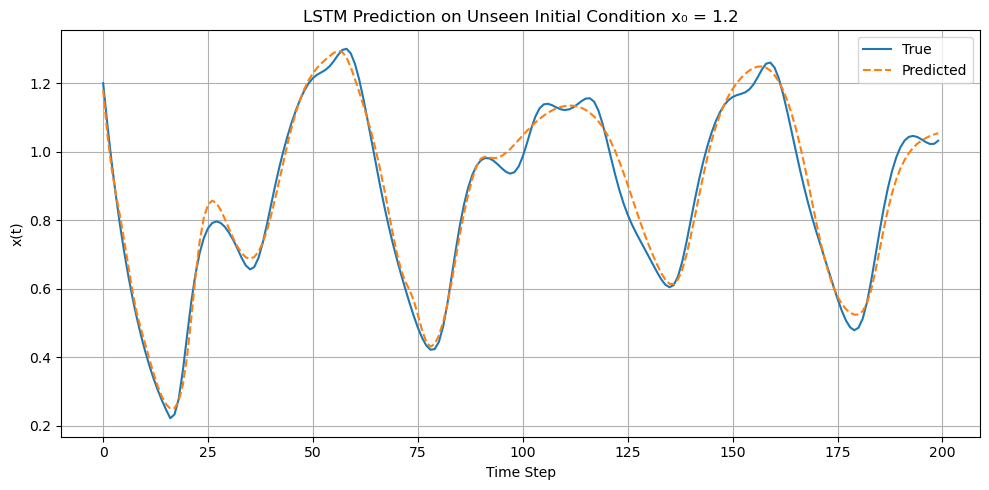

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import time

# --- Use GPU if available ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Parameters ---
t_max = 200
delta_t = 1
train_ics_left = np.linspace(0, 1.19, 20)
train_ics_right = np.linspace(1.21, 3, 20)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 1.2
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data ---
X_list, y_list = [], []
for ic in train_ics:
    x = mackey_glass(t_max=t_max, x0=ic)
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# --- Generate test data ---
x_test = mackey_glass(t_max=200, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Prepare torch datasets ---
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).reshape(len(train_ics), t_max, 2)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(len(train_ics), t_max)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(0).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(0).to(device)

# Split into train and validation (36 train, 4 val)
val_split = 1
train_len = len(train_ics) - val_split
train_dataset, val_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_len, val_split])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

# --- LSTM model ---
class LSTMNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, num_layers=3):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out).squeeze(-1)
        return out

model = LSTMNet().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Early stopping params ---
best_val_loss = float('inf')
patience = 40
patience_counter = 0
best_model_state = None

# --- Train the model ---
epochs = 200
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for xb_val, yb_val in val_loader:
            xb_val, yb_val = xb_val.to(device), yb_val.to(device)
            val_output = model(xb_val)
            val_loss += criterion(val_output, yb_val).item()
        val_loss /= len(val_loader)

    print(f"Epoch {epoch:03d}: Train Loss = {total_loss:.4f}, Val Loss = {val_loss:.4f}")

    # Check early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# --- Load best model ---
model.load_state_dict(best_model_state)
start_time = time.time()
# --- Predict on test IC ---
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor).squeeze(0).cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")
end_time = time.time()
# --- Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(pred_test, label='Predicted', linestyle='--')
plt.title(f"LSTM Prediction on Unseen Initial Condition x₀ = {test_ic}")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


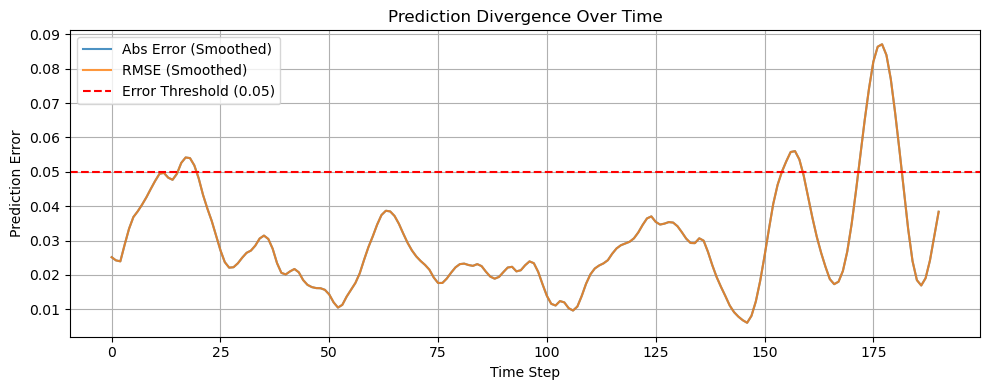

Prediction horizon at threshold 0.05: 16 steps
Total runtime: 0.00 seconds


In [25]:
# Divergence
errors = np.abs(pred_test - y_test)            # abs error
rmse_window = np.sqrt((pred_test - y_test)**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

threshold = 0.05
divergence_time = np.argmax(smoothed_error > threshold)
print(f"Prediction horizon at threshold {threshold}: {divergence_time} steps")


print(f"Total runtime: {end_time - start_time:.2f} seconds")


In [ ]:
from scipy.stats import pearsonr, spearmanr

def correlation_metrics(y_true, y_pred):
    pearson_corr, _ = pearsonr(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)
    return pearson_corr, spearman_corr

pearson_corr, spearman_corr = correlation_metrics(y_test, pred_test)
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")


In [ ]:
from scipy.signal import welch
from numpy.linalg import norm

def spectral_similarity(y_true, y_pred, fs=1.0):
    # Welch’s method for power spectral density (PSD)
    f_true, Pxx_true = welch(y_true, fs=fs, nperseg=128)
    f_pred, Pxx_pred = welch(y_pred, fs=fs, nperseg=128)

    # Normalize
    Pxx_true /= np.sum(Pxx_true)
    Pxx_pred /= np.sum(Pxx_pred)

    # Cosine similarity
    cosine_sim = np.dot(Pxx_true, Pxx_pred) / (norm(Pxx_true) * norm(Pxx_pred))
    return cosine_sim, f_true, Pxx_true, Pxx_pred

cos_sim, f, spec_true, spec_pred = spectral_similarity(y_test, pred_test)
print(f"Spectral cosine similarity: {cos_sim:.4f}")

# Plot spectra
plt.figure(figsize=(8,4))
plt.semilogy(f, spec_true, label="True PSD")
plt.semilogy(f, spec_pred, label="Predicted PSD")
plt.title("Power Spectrum Comparison")
plt.xlabel("Frequency")
plt.ylabel("Normalized Power")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from nolitsa import lyapunov

def estimate_lyapunov(y, emb_dim=6, tau=2, window=20):
    """Estimate largest Lyapunov exponent using Rosenstein’s algorithm."""
    n = len(y)
    # Embed trajectory
    # nolitsa.lyapunov.mle returns (exponent, etc.)
    lle, _ = lyapunov.mle(y, emb_dim=emb_dim, tau=tau, window=window)
    return np.mean(lle)

lle_true = estimate_lyapunov(y_test)
lle_pred = estimate_lyapunov(pred_test)
print(f"Lyapunov exponent (True): {lle_true:.4f}")
print(f"Lyapunov exponent (Pred): {lle_pred:.4f}")


In [9]:
import torch
from torch.utils.data import DataLoader

# Use CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Expanded hyperparameter search space
hidden_sizes = [32, 64, 128, 256]
num_layers_list = [1, 2, 3]
learning_rates = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
batch_sizes = [4, 8, 16]
dropouts = [0.0, 0.2, 0.4]

# Redefine LSTM model class to accept dropout
class LSTMNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, dropout=0.0):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out).squeeze(-1)
        return out

# Grid search
best_model = None
best_loss = float("inf")
best_config = None

for h in hidden_sizes:
    for l in num_layers_list:
        for lr in learning_rates:
            for bs in batch_sizes:
                for do in dropouts:
                    print(f"\nTraining: hidden={h}, layers={l}, lr={lr}, batch={bs}, dropout={do}")

                    # Define model, optimizer, dataloader
                    model = LSTMNet(hidden_size=h, num_layers=l, dropout=do).to(device)
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)

                    # Train for a few quick epochs
                    for epoch in range(15):
                        model.train()
                        for xb, yb in train_loader:
                            xb, yb = xb.to(device), yb.to(device)
                            optimizer.zero_grad()
                            output = model(xb)
                            loss = criterion(output, yb)
                            loss.backward()
                            optimizer.step()

                    # Evaluate on validation set
                    model.eval()
                    val_loss = 0
                    with torch.no_grad():
                        for xb, yb in val_loader:
                            xb, yb = xb.to(device), yb.to(device)
                            val_loss += criterion(model(xb), yb).item()
                    val_loss /= len(val_loader)
                    print(f"Val Loss: {val_loss:.5f}")

                    # Save best model
                    if val_loss < best_loss:
                        best_loss = val_loss
                        best_model = model
                        best_config = (h, l, lr, bs, do)

print(f"\n✅ Best Config: Hidden={best_config[0]}, Layers={best_config[1]}, "
      f"LR={best_config[2]}, Batch={best_config[3]}, Dropout={best_config[4]} "
      f"→ Val Loss={best_loss:.5f}")


Using device: cuda

Training: hidden=32, layers=1, lr=0.01, batch=4, dropout=0.0
Val Loss: 0.05354

Training: hidden=32, layers=1, lr=0.01, batch=4, dropout=0.2
Val Loss: 0.05899

Training: hidden=32, layers=1, lr=0.01, batch=4, dropout=0.4
Val Loss: 0.05055

Training: hidden=32, layers=1, lr=0.01, batch=8, dropout=0.0
Val Loss: 0.06360

Training: hidden=32, layers=1, lr=0.01, batch=8, dropout=0.2
Val Loss: 0.06794

Training: hidden=32, layers=1, lr=0.01, batch=8, dropout=0.4
Val Loss: 0.06519

Training: hidden=32, layers=1, lr=0.01, batch=16, dropout=0.0
Val Loss: 0.07151

Training: hidden=32, layers=1, lr=0.01, batch=16, dropout=0.2
Val Loss: 0.06962

Training: hidden=32, layers=1, lr=0.01, batch=16, dropout=0.4
Val Loss: 0.06263

Training: hidden=32, layers=1, lr=0.005, batch=4, dropout=0.0
Val Loss: 0.06231

Training: hidden=32, layers=1, lr=0.005, batch=4, dropout=0.2
Val Loss: 0.06488

Training: hidden=32, layers=1, lr=0.005, batch=4, dropout=0.4
Val Loss: 0.05254

Training: hidd

In [48]:
import torch
import torch.nn as nn

class LSTMNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, dropout=0.0):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out).squeeze(-1)
        return out


In [50]:
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.MSELoss()

search_space = [
    Integer(32, 256, name="hidden_size"),
    Integer(1, 3, name="num_layers"),
    Real(1e-4, 1e-2, prior="log-uniform", name="learning_rate"),
    Real(0.0, 0.5, name="dropout"),
    Integer(4, 16, name="batch_size"),
]

@use_named_args(search_space)
def objective(hidden_size, num_layers, learning_rate, dropout, batch_size):
    # Convert all parameters to native Python types
    hidden_size = int(hidden_size)
    num_layers = int(num_layers)
    batch_size = int(batch_size)
    learning_rate = float(learning_rate)
    dropout = float(dropout)

    model = LSTMNet(hidden_size=hidden_size, num_layers=num_layers, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(10):  # quick training
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb), yb).item()

    return val_loss / len(val_loader)


In [52]:
search_result = gp_minimize(
    func=objective,
    dimensions=search_space,
    acq_func="EI",      # Expected Improvement
    n_calls=30,         # You can increase this for better results
    random_state=42,
    verbose=True
)


Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.7105
Function value obtained: 0.0809
Current minimum: 0.0809
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.1105
Function value obtained: 0.0793
Current minimum: 0.0793
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0774
Function value obtained: 0.0646
Current minimum: 0.0646
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.5771
Function value obtained: 0.3761
Current minimum: 0.0646
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.1856
Function value obtained: 0.0659
Current minimum: 0.0646
Iteration No: 6 started. Evaluating

In [27]:
best_params = search_result.x
best_loss = search_result.fun

print("\nBest Hyperparameters:")
print(f"Hidden Size: {best_params[0]}")
print(f"Num Layers: {best_params[1]}")
print(f"Learning Rate: {best_params[2]:.5f}")
print(f"Dropout: {best_params[3]:.2f}")
print(f"Batch Size: {best_params[4]}")
print(f"Validation Loss: {best_loss:.4f}")



Best Hyperparameters:
Hidden Size: 122
Num Layers: 1
Learning Rate: 0.00886
Dropout: 0.12
Batch Size: 5
Validation Loss: 0.0539
